In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5\final(works)")

## Section 1 : Import libraries and helper functions

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [7]:
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [8]:
SCALED_MODELS = {'Logistic Regression', 'KNN', 'SVC', 'Naive Bayes'}

MODEL_COLORS = {
    'Logistic Regression':'#3498DB', 'Naive Bayes':'#1ABC9C',
    'KNN':'#F39C12',                 'Decision Tree':'#E67E22',
    'Random Forest':'#2ECC71',       'Extra Trees':'#27AE60',
    'AdaBoost':'#E74C3C',            'Gradient Boosting':'#C0392B',
    'XGBoost':'#8E44AD',             'SVC':'#2C3E50',
}

In [9]:
def encode_features(df):
    df = df.copy()
    for col in ['Family History','Smoking','Alcohol Consumption','Prior Fractures']:
        df[col] = df[col].map({'Yes':1,'No':0})
    df['Hormonal Changes']  = df['Hormonal Changes'].map({'Normal':0,'Postmenopausal':1})
    df['Body Weight']       = df['Body Weight'].map({'Underweight':0,'Normal':1,'Overweight':2})
    df['Calcium Intake']    = df['Calcium Intake'].map({'Low':0,'Adequate':1})
    df['Vitamin D Intake']  = df['Vitamin D Intake'].map({'Insufficient':0,'Sufficient':1})
    df['Physical Activity'] = df['Physical Activity'].map({'Sedentary':0,'Moderate':1,'Active':2})
    df['Gender']            = df['Gender'].map({'Female':1,'Male':0})
    df = pd.get_dummies(df, columns=['Race/Ethnicity','Medical Conditions','Medications'], drop_first=True)
    return df

In [10]:
def add_features(df):
    df = df.copy()
    df['Nutrient_Deficiency'] = ((df['Calcium Intake']==0)|(df['Vitamin D Intake']==0)).astype(int)
    df['Lifestyle_Risk']      = df['Smoking'] + df['Alcohol Consumption']
    df['Age_Group']           = pd.cut(df['Age'],bins=[0,40,55,70,120],labels=[0,1,2,3]).astype(int)
    df['Hormonal_Bone_Risk']  = df['Hormonal Changes'] * df['Family History']
    return df

In [11]:
def get_X(name, X_scaled, X_raw):
    return X_scaled if name in SCALED_MODELS else X_raw

def get_metrics(model, X, y):
    p = model.predict(X)
    return {
        'Accuracy':  round(accuracy_score(y, p), 4),
        'Precision': round(precision_score(y, p, zero_division=0), 4),
        'Recall':    round(recall_score(y, p, zero_division=0), 4),
        'F1 Score':  round(f1_score(y, p, zero_division=0), 4),
    }

In [12]:
def plot_metric_bar(df, metric, ax, title=None):
    df_s = df.sort_values(metric, ascending=True)
    colors = [MODEL_COLORS.get(m,'#95A5A6') for m in df_s['Model']]
    bars = ax.barh(df_s['Model'], df_s[metric], color=colors, edgecolor='white', height=0.6)
    bars[-1].set_edgecolor('gold'); bars[-1].set_linewidth(2.5)
    ax.set_xlabel(metric)
    ax.set_title(title or metric, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.12)
    for bar in bars:
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)

print('Helper functions ready.')
print('9 models: LR, NB, KNN, DT, RF, ET, AdaBoost, GB, XGBoost + SVC')

Helper functions ready.
9 models: LR, NB, KNN, DT, RF, ET, AdaBoost, GB, XGBoost + SVC


## Section 2 : Load Data

In [14]:
df = pd.read_csv("D:\FQL\PJ 5\osteoporosis.csv")
df.drop(columns=['ID'], inplace=True, errors='ignore')
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
print(f'Shape: {df.shape} | Missing: {df.isnull().sum().sum()}')
df.head()

Shape: (1958, 16) | Missing: 0


,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,Moderate,Hyperthyroidism,Corticosteroids,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1


## Section 3 : Data Leakage Audit

In [15]:
checks = [
    ('Encoding uses target stats?',        'No - pure domain mappings'),
    ('Scaler fit on train only?',          'ENFORCED - fit_transform(X_train) only'),
    ('CV done on train set only?',         'ENFORCED - GridSearchCV uses X_train'),
    ('Engineered features use future?',    'No - all row-level computations'),
    ('Baseline trained BEFORE GridSearch?','Yes - correct workflow enforced'),
    ('Test set sealed until NB3?',         'Yes - never seen during training'),
]
print('=' * 58)
print('  DATA LEAKAGE AUDIT')
print('=' * 58)
for check, status in checks:
    flag = 'PASS' if any(x in status for x in ['No','ENFORCED','Yes']) else 'WARN'
    print(f'  [{flag}] {check}')
    print(f'         {status}')
print('Audit passed.')

  DATA LEAKAGE AUDIT
  [PASS] Encoding uses target stats?
         No - pure domain mappings
  [PASS] Scaler fit on train only?
         ENFORCED - fit_transform(X_train) only
  [PASS] CV done on train set only?
         ENFORCED - GridSearchCV uses X_train
  [PASS] Engineered features use future?
         No - all row-level computations
  [PASS] Baseline trained BEFORE GridSearch?
         Yes - correct workflow enforced
  [PASS] Test set sealed until NB3?
         Yes - never seen during training
Audit passed.


## Section 4 : Train/ Test Split

In [18]:
X_raw = df.drop(columns=['Osteoporosis'])
y     = df['Osteoporosis'].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {len(X_train_raw)} | Test: {len(X_test_raw)}')
print(f'Positive rate (train): {y_train.mean()*100:.1f}%')

Train: 1566 | Test: 392
Positive rate (train): 50.0%


## Section 5 : Encoding & Scaling 

In [19]:
X_train_enc = encode_features(X_train_raw)
X_test_enc  = encode_features(X_test_raw)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

In [31]:
# ── Fix: Alcohol Consumption actual value is 'Moderate' ──────────
# encode_features maps Yes/No but data has 'Moderate' → becomes NaN

# Check all unique values
print("Alcohol Consumption unique:", X_train_raw['Alcohol Consumption'].unique())

# Force fill — all values are 'Moderate' = drinking = 1
X_train_fe['Alcohol Consumption'] = 1
X_test_fe['Alcohol Consumption']  = 1

# Recalculate Lifestyle_Risk which depends on Alcohol Consumption
X_train_fe['Lifestyle_Risk'] = X_train_fe['Smoking'] + X_train_fe['Alcohol Consumption']
X_test_fe['Lifestyle_Risk']  = X_test_fe['Smoking']  + X_test_fe['Alcohol Consumption']

print("NaNs in X_train_fe:", X_train_fe.isnull().sum().sum())
print("NaNs per column:")
print(X_train_fe.isnull().sum()[X_train_fe.isnull().sum() > 0])

# Re-do scaling on clean data
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

print("\nNaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("Shape:", X_train_scaled.shape)

Alcohol Consumption unique: ['Moderate']
NaNs in X_train_fe: 0
NaNs per column:
Series([], dtype: int64)

NaNs in X_train_scaled: 0
Shape: (1566, 19)


In [26]:
X_train_fe = add_features(X_train_enc)
X_test_fe  = add_features(X_test_enc)
feature_names = list(X_train_fe.columns)

In [27]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

In [28]:
print(f'Features: {len(feature_names)}')
print('Engineered: Nutrient_Deficiency, Lifestyle_Risk, Age_Group, Hormonal_Bone_Risk')
print('Scaler fitted on training data only.')

Features: 19
Engineered: Nutrient_Deficiency, Lifestyle_Risk, Age_Group, Hormonal_Bone_Risk
Scaler fitted on training data only.


In [32]:
def encode_features(df):
    df = df.copy()
    for col in ['Family History', 'Smoking', 'Prior Fractures']:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Alcohol Consumption — actual values: 'Never', 'Moderate', 'Regularly'
    df['Alcohol Consumption'] = df['Alcohol Consumption'].map(
        {'No': 0, 'Never': 0, 'Yes': 1, 'Moderate': 1, 'Regularly': 1, 'Occasionally': 1}
    )

    df['Hormonal Changes']  = df['Hormonal Changes'].map({'Normal': 0, 'Postmenopausal': 1})
    df['Body Weight']       = df['Body Weight'].map({'Underweight': 0, 'Normal': 1, 'Overweight': 2})
    df['Calcium Intake']    = df['Calcium Intake'].map({'Low': 0, 'Adequate': 1})
    df['Vitamin D Intake']  = df['Vitamin D Intake'].map({'Insufficient': 0, 'Sufficient': 1})
    df['Physical Activity'] = df['Physical Activity'].map({'Sedentary': 0, 'Moderate': 1, 'Active': 2})
    df['Hormonal Changes']  = df['Hormonal Changes'].map({'Normal': 0, 'Postmenopausal': 1})
    df['Gender']            = df['Gender'].map({'Female': 1, 'Male': 0})
    df = pd.get_dummies(df, columns=['Race/Ethnicity', 'Medical Conditions', 'Medications'], drop_first=True)
    return df

# Section 6 : Baseline Training Models (All 9 Models)

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes':         GaussianNB(),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'Extra Trees':         ExtraTreesClassifier(random_state=RANDOM_STATE),
    'AdaBoost':            AdaBoostClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                          random_state=RANDOM_STATE, verbosity=0),
    'SVC':                 SVC(probability=True, random_state=RANDOM_STATE),
}

In [34]:
baseline_results = []
fitted_baselines = {}

print('Training 9 baseline models (default params)...')
print('-' * 70)

for name, model in baseline_configs.items():
    X_tr  = get_X(name, X_train_scaled, X_train_fe.values)
    cv_f1 = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1')
    model.fit(X_tr, y_train)
    fitted_baselines[name] = model
    m    = get_metrics(model, X_tr, y_train)
    gap  = m['Accuracy'] - cv_f1.mean()
    note = 'OVERFIT' if gap > 0.15 else 'OK'
    baseline_results.append({'Model':name, 'CV F1 Mean':round(cv_f1.mean(),4),
                              'CV F1 Std':round(cv_f1.std(),4), **m})
    print(f'  {name:<22}  CV F1={cv_f1.mean():.4f}(+/-{cv_f1.std():.4f})  Acc={m["Accuracy"]:.4f}  {note}')

baseline_df = pd.DataFrame(baseline_results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
print('Baseline training complete.')

Training 9 baseline models (default params)...
----------------------------------------------------------------------
  Logistic Regression     CV F1=0.8278(+/-0.0197)  Acc=0.8557  OK
  Naive Bayes             CV F1=0.8248(+/-0.0215)  Acc=0.8512  OK
  KNN                     CV F1=0.7458(+/-0.0172)  Acc=0.8442  OK
  Decision Tree           CV F1=0.8730(+/-0.0094)  Acc=1.0000  OK
  Random Forest           CV F1=0.8376(+/-0.0285)  Acc=1.0000  OVERFIT
  Extra Trees             CV F1=0.8208(+/-0.0236)  Acc=1.0000  OVERFIT
  AdaBoost                CV F1=0.8460(+/-0.0306)  Acc=0.8633  OK
  Gradient Boosting       CV F1=0.9127(+/-0.0088)  Acc=0.9285  OK
  XGBoost                 CV F1=0.8869(+/-0.0109)  Acc=1.0000  OK
  SVC                     CV F1=0.8259(+/-0.0215)  Acc=0.8602  OK
Baseline training complete.


## Section 7 : Baseline Perfromance Analysis

In [35]:
print('=== Baseline Performance — 9 Models ===')
display(baseline_df.style
        .highlight_max(subset=['CV F1 Mean','F1 Score'], color='#d4edda')
        .highlight_min(subset=['CV F1 Std'], color='#d4edda')
        .format({'CV F1 Mean':'{:.4f}','CV F1 Std':'{:.4f}',
                 'Accuracy':'{:.4f}','Precision':'{:.4f}',
                 'Recall':'{:.4f}','F1 Score':'{:.4f}'}))

=== Baseline Performance — 9 Models ===


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.9127,0.0088,0.9285,1.0000,0.8570,0.9230
1,XGBoost,0.8869,0.0109,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,0.8730,0.0094,1.0000,1.0000,1.0000,1.0000
3,AdaBoost,0.8460,0.0306,0.8633,1.0000,0.7267,0.8417
4,Random Forest,0.8376,0.0285,1.0000,1.0000,1.0000,1.0000
5,Logistic Regression,0.8278,0.0197,0.8557,0.9696,0.7344,0.8358
6,SVC,0.8259,0.0215,0.8602,1.0000,0.7203,0.8374
7,Naive Bayes,0.8248,0.0215,0.8512,1.0000,0.7024,0.8252
8,Extra Trees,0.8208,0.0236,1.0000,1.0000,1.0000,1.0000
9,KNN,0.7458,0.0172,0.8442,0.9102,0.7637,0.8306


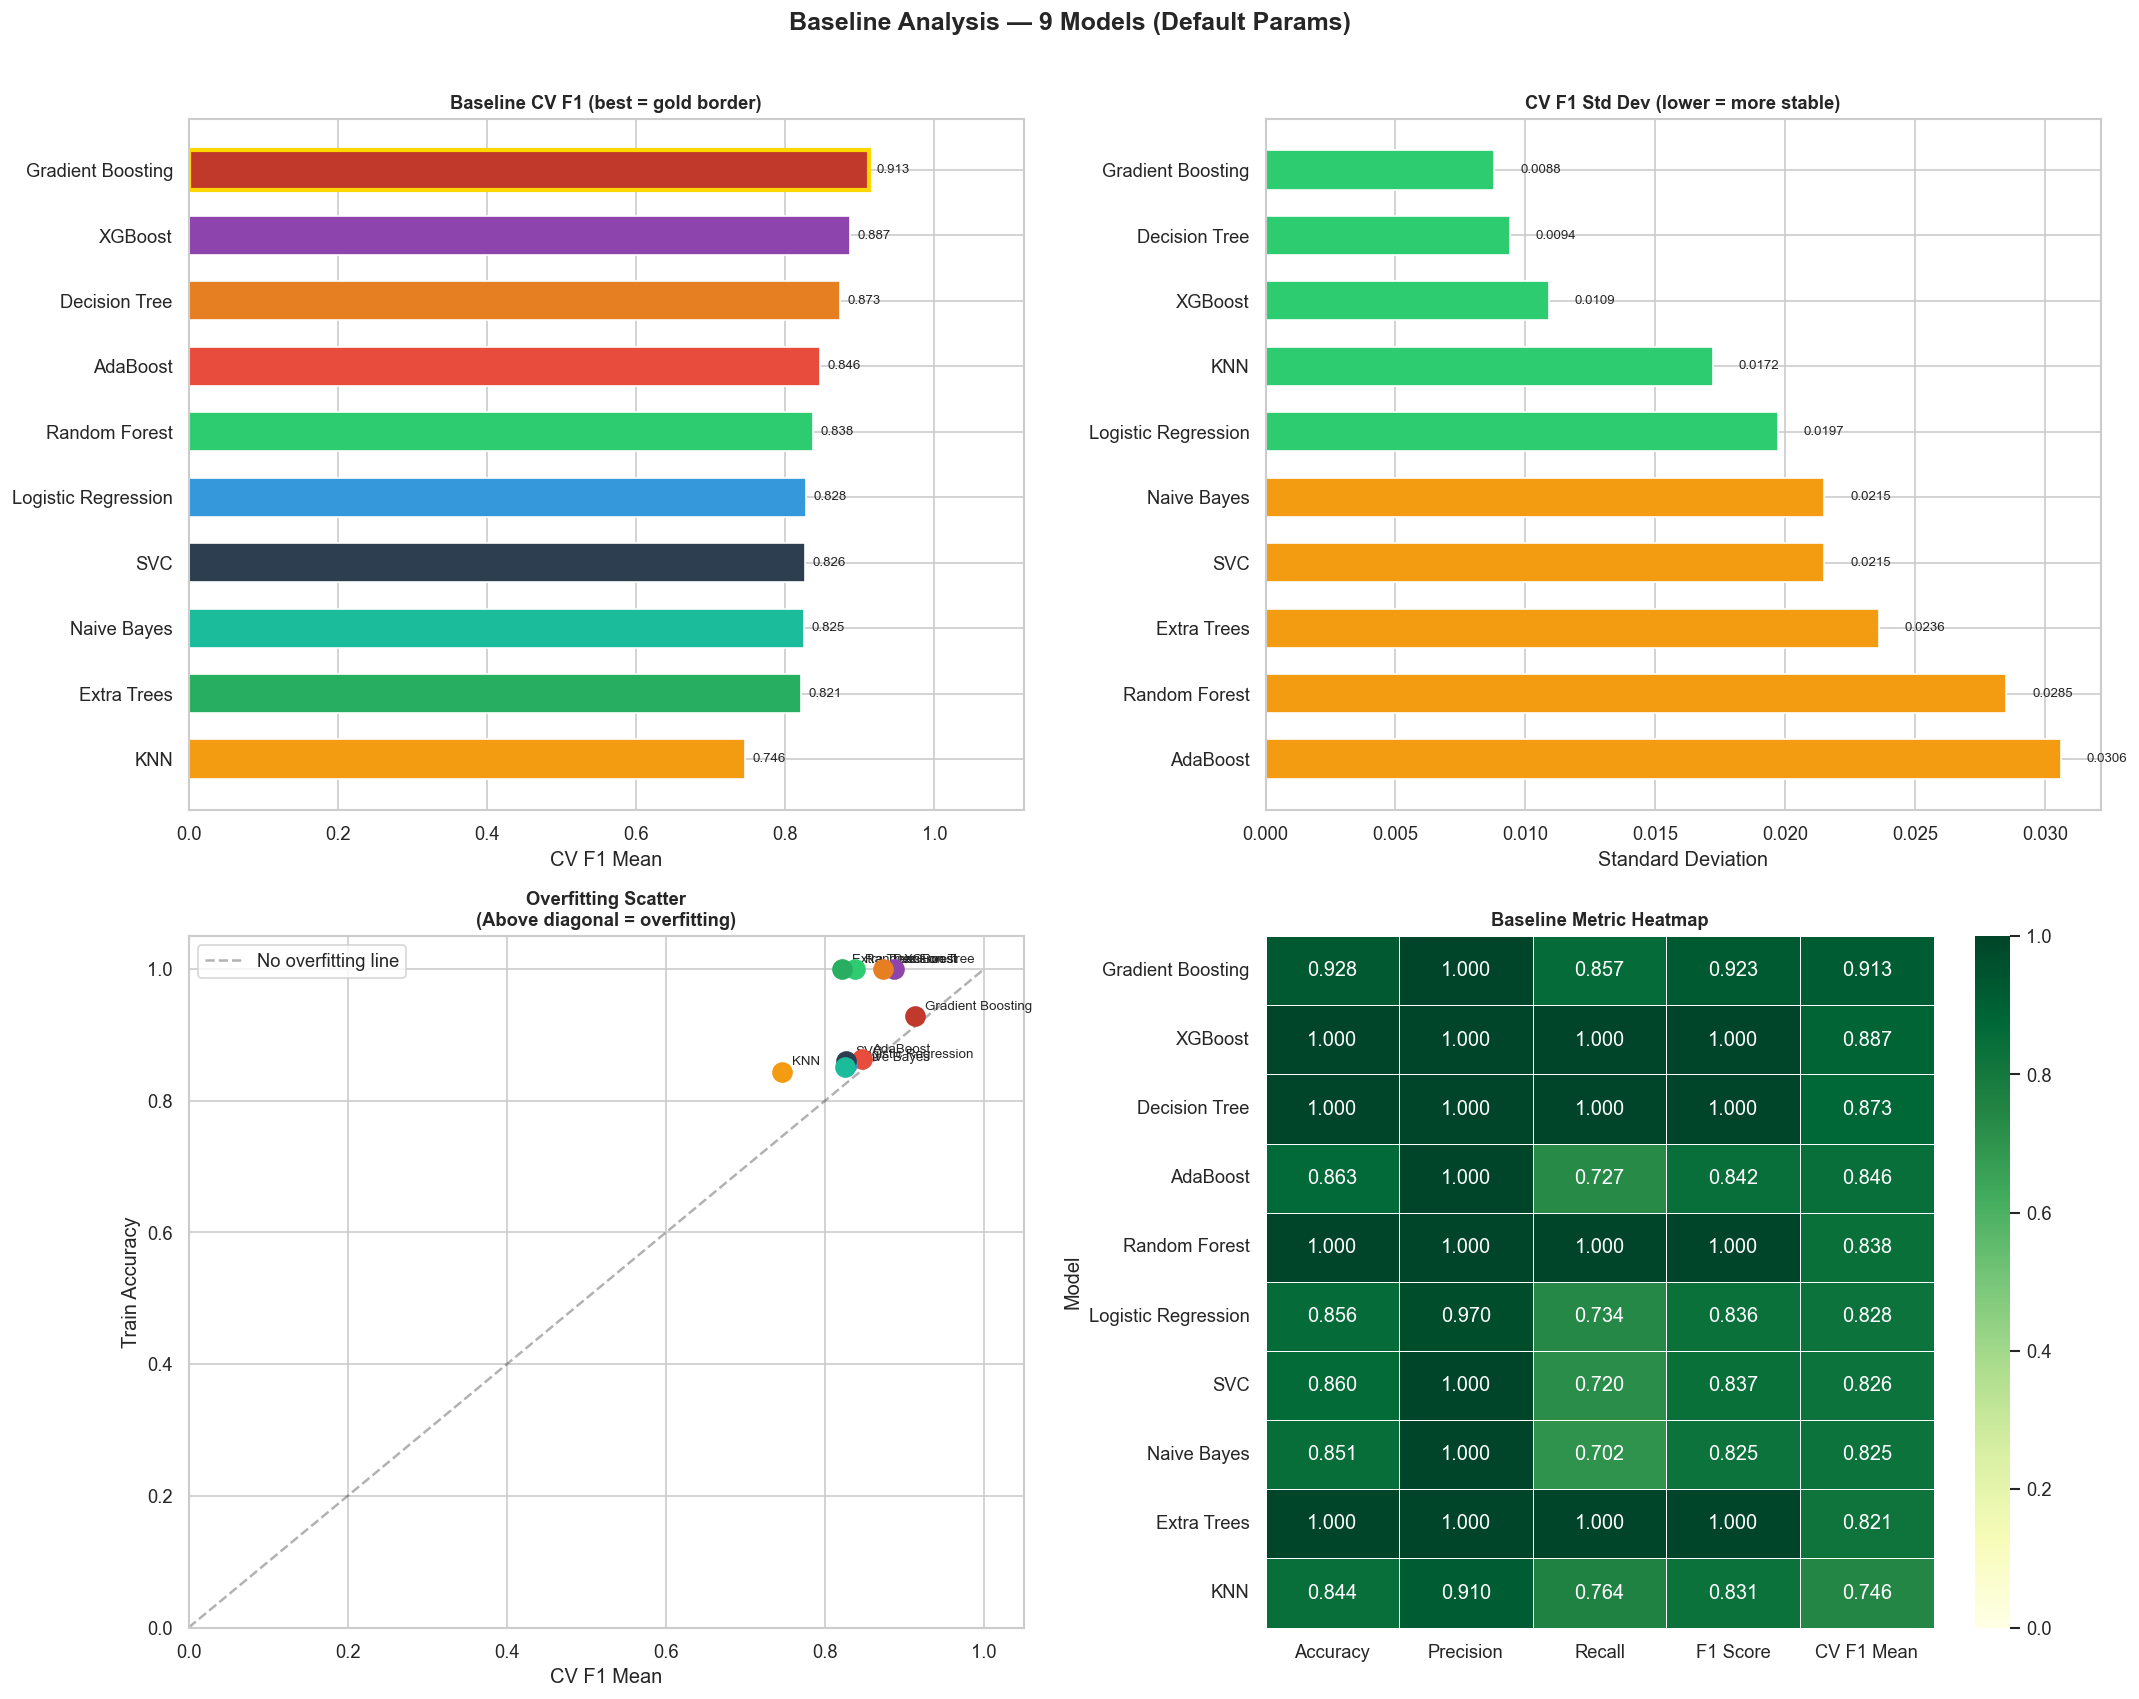

Best:  Gradient Boosting  CV F1=0.9127
Worst: KNN  CV F1=0.7458


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# CV F1 bar
plot_metric_bar(baseline_df, 'CV F1 Mean', axes[0,0], 'Baseline CV F1 (best = gold border)')

# Std dev bar
df_std = baseline_df.sort_values('CV F1 Std', ascending=False)
std_colors = ['#E74C3C' if v>0.05 else '#F39C12' if v>0.02 else '#2ECC71'
              for v in df_std['CV F1 Std']]
axes[0,1].barh(df_std['Model'], df_std['CV F1 Std'], color=std_colors, edgecolor='white', height=0.6)
axes[0,1].set_title('CV F1 Std Dev (lower = more stable)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Standard Deviation')
for bar in axes[0,1].patches:
    axes[0,1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                   f'{bar.get_width():.4f}', va='center', fontsize=8)

# Overfitting scatter
for _, row in baseline_df.iterrows():
    axes[1,0].scatter(row['CV F1 Mean'], row['Accuracy'],
                      color=MODEL_COLORS.get(row['Model'],'gray'), s=130, zorder=5)
    axes[1,0].annotate(row['Model'], (row['CV F1 Mean'], row['Accuracy']),
                       textcoords='offset points', xytext=(6,4), fontsize=8)
axes[1,0].plot([0,1],[0,1],'k--',alpha=0.3, label='No overfitting line')
axes[1,0].set_xlabel('CV F1 Mean'); axes[1,0].set_ylabel('Train Accuracy')
axes[1,0].set_title('Overfitting Scatter\n(Above diagonal = overfitting)', fontsize=11, fontweight='bold')
axes[1,0].legend(); axes[1,0].set_xlim(0,1.05); axes[1,0].set_ylim(0,1.05)

# Heatmap
heat = baseline_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score','CV F1 Mean']]
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1,1], linewidths=0.5, vmin=0, vmax=1)
axes[1,1].set_title('Baseline Metric Heatmap', fontsize=11, fontweight='bold')

plt.suptitle('Baseline Analysis — 9 Models (Default Params)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plots/1_BAseline_analysis.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()
print(f'Best:  {baseline_df.iloc[0]["Model"]}  CV F1={baseline_df.iloc[0]["CV F1 Mean"]:.4f}')
print(f'Worst: {baseline_df.iloc[-1]["Model"]}  CV F1={baseline_df.iloc[-1]["CV F1 Mean"]:.4f}')

## Section 8 : Hyperparameter Tuning - GridSeaarch

| Model | Key Params | Rationale |
|-------|------------|-----------|
| Logistic Regression | C, solver | Regularization strength + algorithm |
| Naive Bayes | var_smoothing | Numerical stability of variance |
| KNN | n_neighbors, metric | Distance neighbours + metric |
| Decision Tree | max_depth, criterion, min_samples_leaf | Overfitting control |
| Random Forest | n_estimators, max_depth, max_features | Ensemble size + sampling |
| Extra Trees | n_estimators, max_depth, max_features | Same as RF, more randomised |
| AdaBoost | n_estimators, learning_rate | Weak learners + step size |
| Gradient Boosting | n_estimators, learning_rate, max_depth | Classic boosting tradeoff |
| XGBoost | n_estimators, learning_rate, max_depth, subsample | Full regularisation |
| SVC | C, kernel, gamma | Margin + kernel + bandwidth |

In [38]:
param_grids = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'params': {'C':[0.01,0.1,1,10,100], 'solver':['lbfgs','liblinear']}
    },
    'Naive Bayes': {
        'estimator': GaussianNB(),
        'params': {'var_smoothing': np.logspace(-12,-6,7).tolist()}
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {'n_neighbors':[3,5,7,9,11,15], 'metric':['euclidean','manhattan']}
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {'max_depth':[3,5,7,10,None], 'min_samples_leaf':[1,2,4],
                   'criterion':['gini','entropy']}
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators':[100,200,300], 'max_depth':[5,10,None],
                   'max_features':['sqrt','log2']}
    },
    'Extra Trees': {
        'estimator': ExtraTreesClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators':[100,200,300], 'max_depth':[5,10,None],
                   'max_features':['sqrt','log2']}
    },
    'AdaBoost': {
        'estimator': AdaBoostClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators':[50,100,200], 'learning_rate':[0.01,0.1,0.5,1.0]}
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators':[100,200], 'learning_rate':[0.05,0.1,0.2],
                   'max_depth':[3,5,7]}
    },
    'XGBoost': {
        'estimator': XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                    random_state=RANDOM_STATE, verbosity=0),
        'params': {'n_estimators':[100,200,300], 'learning_rate':[0.05,0.1,0.2],
                   'max_depth':[3,5,7], 'subsample':[0.8,1.0]}
    },
    'SVC': {
        'estimator': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {'C':[0.1,1,10], 'kernel':['rbf','linear'], 'gamma':['scale','auto']}
    },
}

In [39]:
tuned_models  = {}
grid_objects  = {}
tuned_results = []

In [40]:
print('Running GridSearchCV — all 9 models (train set only)...')
print('-' * 65)
for name, cfg in param_grids.items():
    X_tr = get_X(name, X_train_scaled, X_train_fe.values)
    grid = GridSearchCV(cfg['estimator'], cfg['params'],
                        cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)
    grid.fit(X_tr, y_train)
    m = get_metrics(grid.best_estimator_, X_tr, y_train)
    tuned_models[name] = grid.best_estimator_
    grid_objects[name] = grid
    tuned_results.append({'Model':name, 'CV F1 Mean':round(grid.best_score_,4),
                          'Best Params':str(grid.best_params_), **m})
    print(f'  {name:<22}  CV F1={grid.best_score_:.4f}  Best: {grid.best_params_}')

tuned_df = pd.DataFrame(tuned_results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
print('GridSearchCV complete.')

Running GridSearchCV — all 9 models (train set only)...
-----------------------------------------------------------------
  Logistic Regression     CV F1=0.8316  Best: {'C': 0.1, 'solver': 'liblinear'}
  Naive Bayes             CV F1=0.8248  Best: {'var_smoothing': 1e-12}
  KNN                     CV F1=0.7860  Best: {'metric': 'manhattan', 'n_neighbors': 9}
  Decision Tree           CV F1=0.9056  Best: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1}
  Random Forest           CV F1=0.8416  Best: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
  Extra Trees             CV F1=0.8300  Best: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
  AdaBoost                CV F1=0.8905  Best: {'learning_rate': 1.0, 'n_estimators': 200}
  Gradient Boosting       CV F1=0.9157  Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  XGBoost                 CV F1=0.9110  Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample

## Section 9 : Grid Search CV - Heatmop

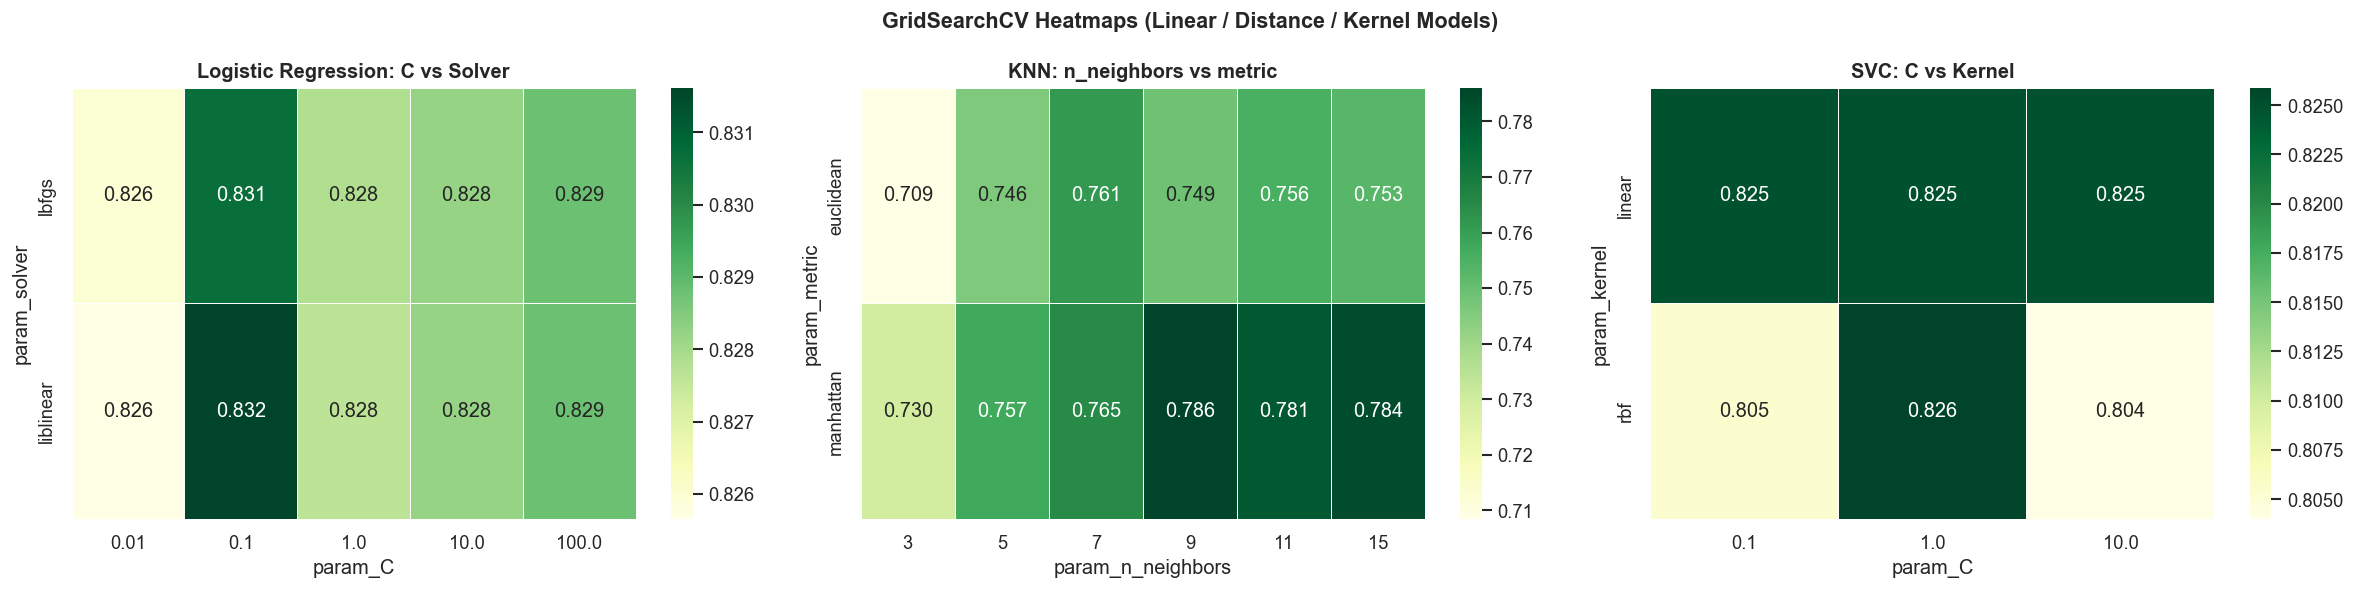

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
# LR
res = pd.DataFrame(grid_objects['Logistic Regression'].cv_results_)
piv = res.pivot_table(index='param_solver', columns='param_C', values='mean_test_score')
sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('Logistic Regression: C vs Solver', fontweight='bold')
# KNN
res2 = pd.DataFrame(grid_objects['KNN'].cv_results_)
piv2 = res2.pivot_table(index='param_metric', columns='param_n_neighbors', values='mean_test_score')
sns.heatmap(piv2, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1], linewidths=0.5)
axes[1].set_title('KNN: n_neighbors vs metric', fontweight='bold')
# SVC
res3 = pd.DataFrame(grid_objects['SVC'].cv_results_)
piv3 = res3.pivot_table(index='param_kernel', columns='param_C', values='mean_test_score')
sns.heatmap(piv3, annot=True, fmt='.3f', cmap='YlGn', ax=axes[2], linewidths=0.5)
axes[2].set_title('SVC: C vs Kernel', fontweight='bold')
plt.suptitle('GridSearchCV Heatmaps (Linear / Distance / Kernel Models)', fontsize=13, fontweight='bold')
plt.savefig('plots/2_Heatmap_CV.png', bbox_inches = 'tight')
plt.tight_layout() 
plt.show()

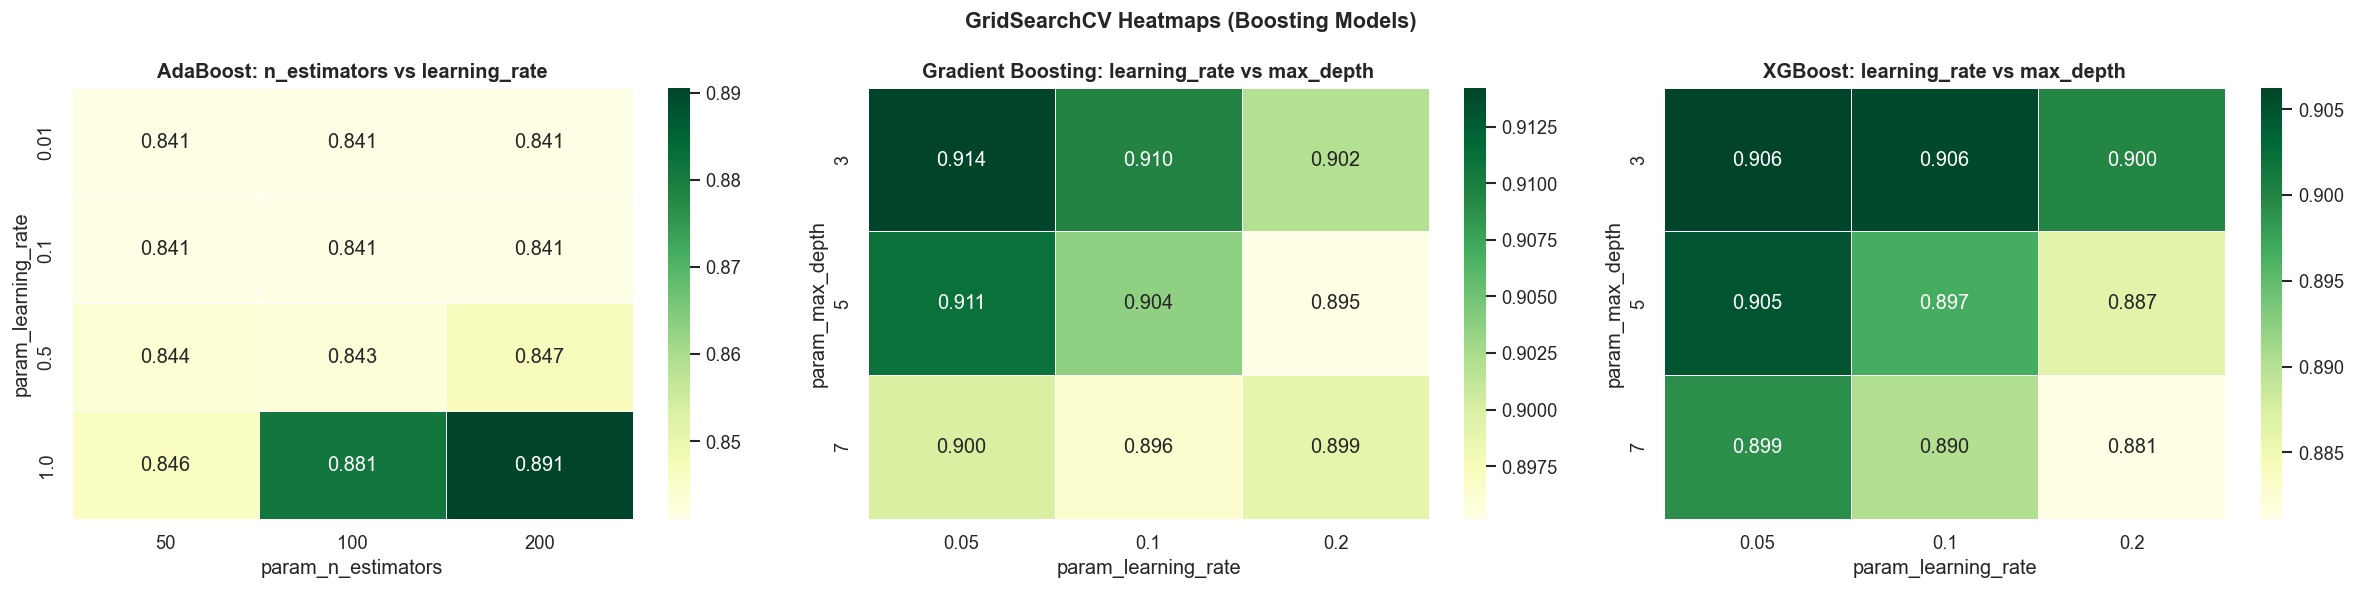

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
# AdaBoost
res4 = pd.DataFrame(grid_objects['AdaBoost'].cv_results_)
piv4 = res4.pivot_table(index='param_learning_rate', columns='param_n_estimators', values='mean_test_score')
sns.heatmap(piv4, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('AdaBoost: n_estimators vs learning_rate', fontweight='bold')
# Gradient Boosting
res5 = pd.DataFrame(grid_objects['Gradient Boosting'].cv_results_)
piv5 = res5.pivot_table(index='param_max_depth', columns='param_learning_rate', values='mean_test_score')
sns.heatmap(piv5, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1], linewidths=0.5)
axes[1].set_title('Gradient Boosting: learning_rate vs max_depth', fontweight='bold')
# XGBoost
res6 = pd.DataFrame(grid_objects['XGBoost'].cv_results_)
piv6 = res6.pivot_table(index='param_max_depth', columns='param_learning_rate', values='mean_test_score')
sns.heatmap(piv6, annot=True, fmt='.3f', cmap='YlGn', ax=axes[2], linewidths=0.5)
axes[2].set_title('XGBoost: learning_rate vs max_depth', fontweight='bold')
plt.suptitle('GridSearchCV Heatmaps (Boosting Models)', fontsize=13, fontweight='bold')
plt.savefig('plots/3_Heatmap_1_CV.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()

## Section 10 : Tuned vs Baseline 

In [48]:
print('================= Tuned Performance — 9 Models =================')
display(tuned_df[['Model','CV F1 Mean','Accuracy','Precision','Recall','F1 Score']].style
        .highlight_max(subset=['CV F1 Mean','F1 Score'], color='#d4edda')
        .format({'CV F1 Mean':'{:.4f}','Accuracy':'{:.4f}',
                 'Precision':'{:.4f}','Recall':'{:.4f}','F1 Score':'{:.4f}'}))

================= Tuned Performance — 9 Models =================


,Model,CV F1 Mean,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.9157,0.9240,1.0000,0.8480,0.9178
1,XGBoost,0.9110,0.9285,1.0000,0.8570,0.9230
2,Decision Tree,0.9056,0.9234,0.9911,0.8544,0.9177
3,AdaBoost,0.8905,0.9061,1.0000,0.8123,0.8964
4,Random Forest,0.8416,0.9591,1.0000,0.9183,0.9574
5,Logistic Regression,0.8316,0.8576,0.9828,0.7280,0.8364
6,Extra Trees,0.8300,0.9483,1.0000,0.8966,0.9455
7,SVC,0.8259,0.8602,1.0000,0.7203,0.8374
8,Naive Bayes,0.8248,0.8512,1.0000,0.7024,0.8252
9,KNN,0.7860,0.8436,0.9622,0.7152,0.8205


In [49]:
delta_rows = []
for _, br in baseline_df.iterrows():
    tr = tuned_df[tuned_df['Model']==br['Model']]
    if len(tr)==0: continue
    tr = tr.iloc[0]
    delta_rows.append({
        'Model':      br['Model'],
        'Base CV F1': br['CV F1 Mean'],
        'Tuned CV F1':tr['CV F1 Mean'],
        'Delta CV F1':round(tr['CV F1 Mean']-br['CV F1 Mean'],4),
        'Delta F1':   round(tr['F1 Score']-br['F1 Score'],4),
        'Delta Acc':  round(tr['Accuracy']-br['Accuracy'],4),
    })

In [53]:
delta_df = pd.DataFrame(delta_rows).sort_values('Delta CV F1', ascending=False)
print('======================== Improvement from Tuning ========================')
display(delta_df.style
        .applymap(lambda v: 'color:green;font-weight:bold' if isinstance(v,float) and v>0
                  else ('color:red' if isinstance(v,float) and v<-0.001 else ''),
                  subset=['Delta CV F1','Delta F1','Delta Acc'])
        .format({'Base CV F1':'{:.4f}','Tuned CV F1':'{:.4f}',
                 'Delta CV F1':'{:+.4f}','Delta F1':'{:+.4f}','Delta Acc':'{:+.4f}'}))

======================== Improvement from Tuning ========================


,Model,Base CV F1,Tuned CV F1,Delta CV F1,Delta F1,Delta Acc
3,AdaBoost,0.8460,0.8905,+0.0445,+0.0547,+0.0428
9,KNN,0.7458,0.7860,+0.0402,-0.0101,-0.0006
2,Decision Tree,0.8730,0.9056,+0.0326,-0.0823,-0.0766
1,XGBoost,0.8869,0.9110,+0.0241,-0.0770,-0.0715
8,Extra Trees,0.8208,0.8300,+0.0092,-0.0545,-0.0517
4,Random Forest,0.8376,0.8416,+0.0040,-0.0426,-0.0409
5,Logistic Regression,0.8278,0.8316,+0.0038,+0.0006,+0.0019
0,Gradient Boosting,0.9127,0.9157,+0.0030,-0.0052,-0.0045
7,Naive Bayes,0.8248,0.8248,+0.0000,+0.0000,+0.0000
6,SVC,0.8259,0.8259,+0.0000,+0.0000,+0.0000


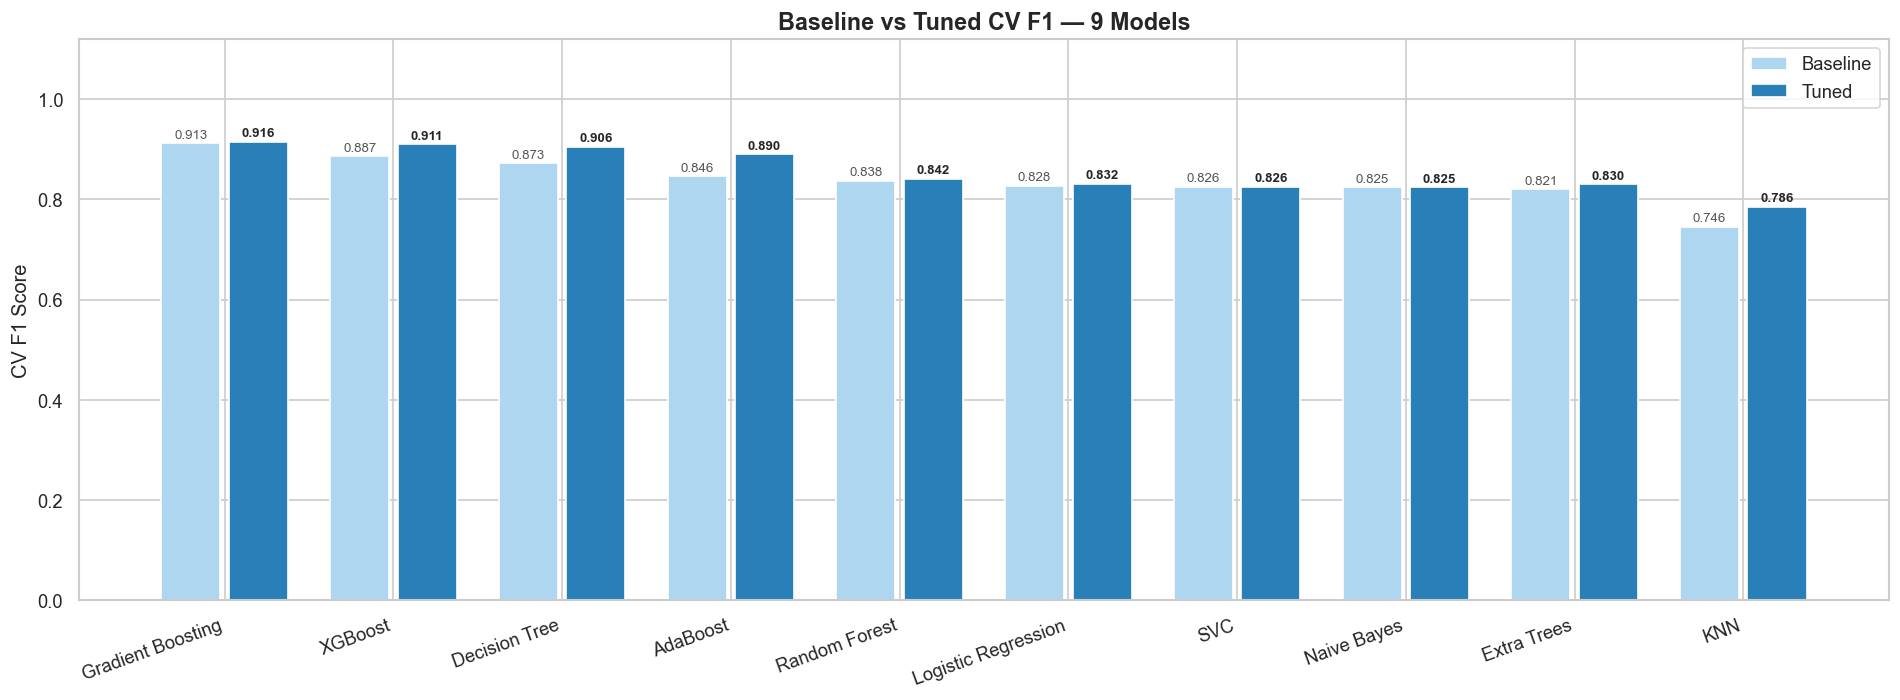

In [54]:
mnames   = baseline_df['Model'].tolist()
base_f1  = [baseline_df[baseline_df['Model']==m]['CV F1 Mean'].values[0] for m in mnames]
tuned_f1 = [tuned_df[tuned_df['Model']==m]['CV F1 Mean'].values[0] for m in mnames]
x = np.arange(len(mnames))

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x-0.2, base_f1,  width=0.35, label='Baseline', color='#AED6F1', edgecolor='white')
ax.bar(x+0.2, tuned_f1, width=0.35, label='Tuned',    color='#2980B9', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(mnames, rotation=20, ha='right')
ax.set_ylim(0, 1.12)
ax.set_title('Baseline vs Tuned CV F1 — 9 Models', fontsize=14, fontweight='bold')
ax.set_ylabel('CV F1 Score')
ax.legend(fontsize=11)
for i, (b, t) in enumerate(zip(base_f1, tuned_f1)):
    ax.text(i-0.2, b+0.01, f'{b:.3f}', ha='center', fontsize=8, color='#555')
    ax.text(i+0.2, t+0.01, f'{t:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.savefig('plots/4_9_CV_F1_score.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()

## Section 11 : Feature Importance

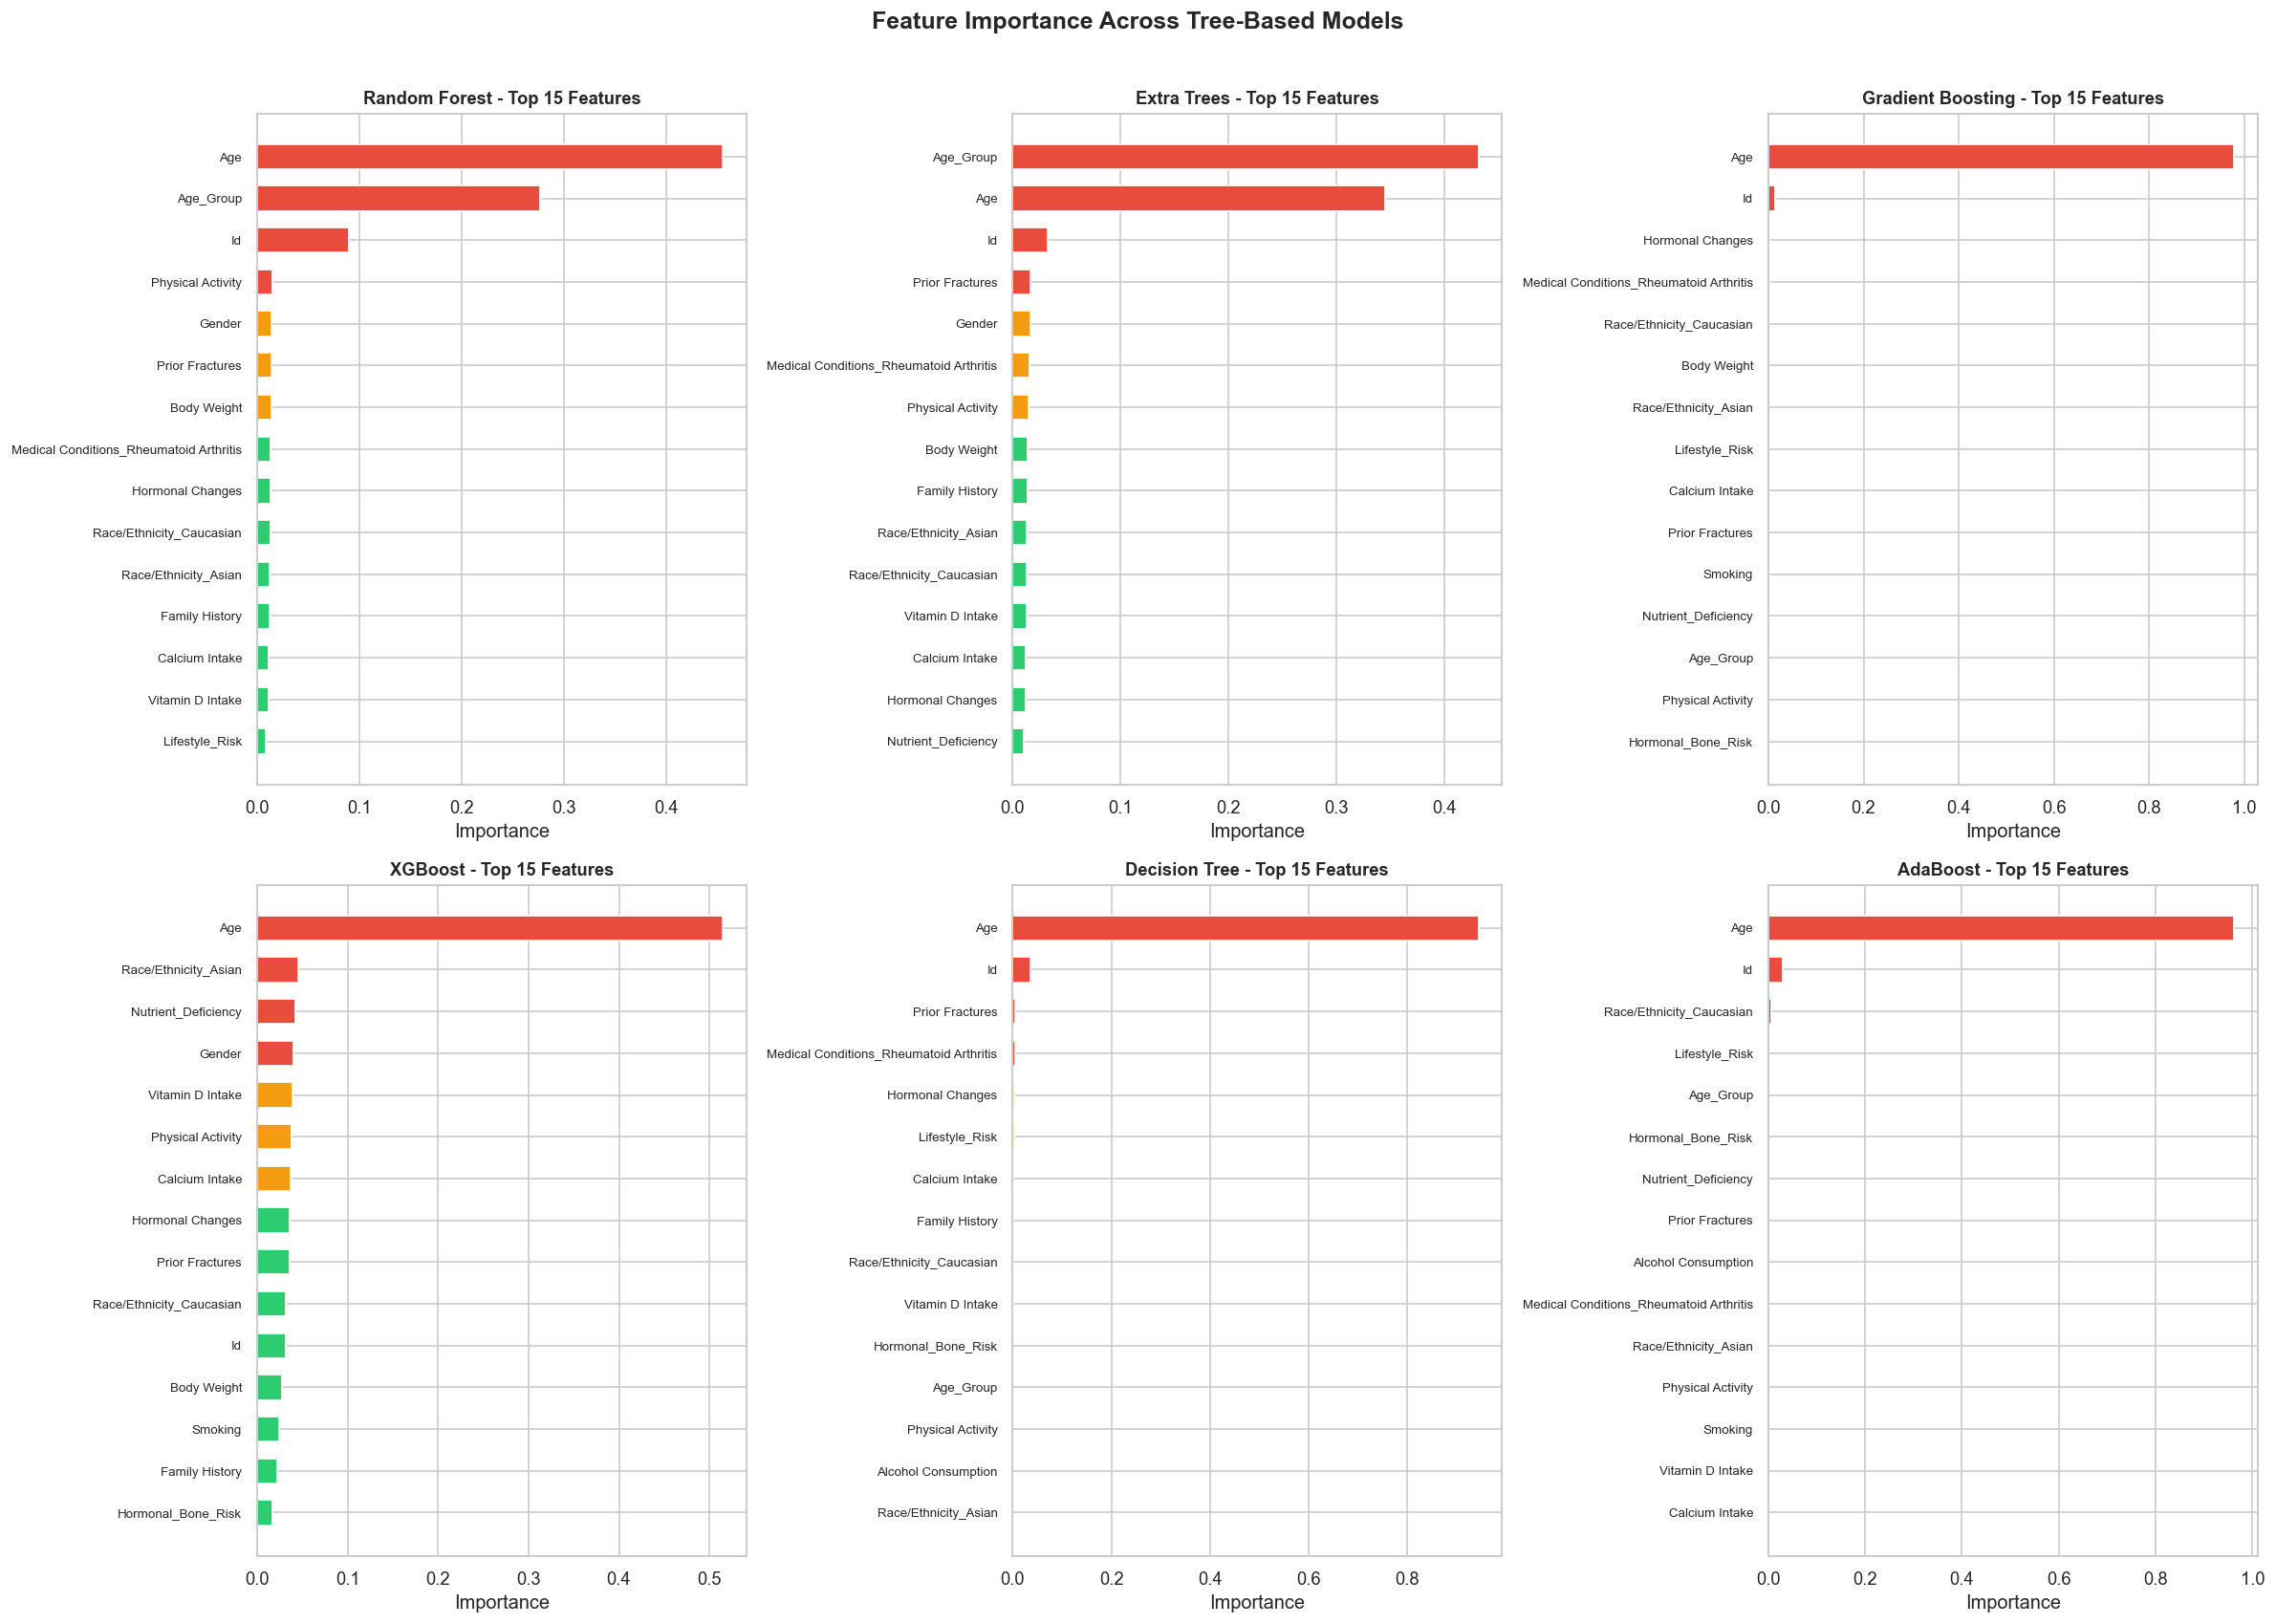

In [57]:
tree_models = [m for m in ['Random Forest','Extra Trees','Gradient Boosting',
                            'XGBoost','Decision Tree','AdaBoost'] if m in tuned_models]
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()
for i, name in enumerate(tree_models):
    model = tuned_models[name]
    imp   = pd.Series(model.feature_importances_, index=feature_names)
    top15 = imp.sort_values(ascending=True).tail(15)
    bar_colors = ['#E74C3C' if v>top15.quantile(0.75)
                  else '#F39C12' if v>top15.quantile(0.5)
                  else '#2ECC71' for v in top15.values]
    axes[i].barh(range(len(top15)), top15.values, color=bar_colors, edgecolor='white', height=0.6)
    axes[i].set_yticks(range(len(top15)))
    axes[i].set_yticklabels(top15.index.tolist(), fontsize=8)
    axes[i].set_title(f'{name} - Top 15 Features', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Importance')
plt.suptitle('Feature Importance Across Tree-Based Models', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plots/Ftr_Imp_Tree.png', bbox_inches = 'tight')
plt.tight_layout()
plt.show()

## Section 12 : save All artifacts

In [58]:
os.makedirs('models', exist_ok=True)
for name, model in tuned_models.items():
    joblib.dump(model, f'models/{name.lower().replace(" ","_")}.pkl')
for name, model in fitted_baselines.items():
    joblib.dump(model, f'models/{name.lower().replace(" ","_")}_baseline.pkl')
joblib.dump(scaler,        'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')
np.save('models/X_test.npy',        X_test_fe.values)
np.save('models/X_test_scaled.npy', X_test_scaled)
np.save('models/y_test.npy',        y_test.values)
baseline_df.to_csv('models/baseline_results.csv', index=False)
tuned_df.to_csv('models/tuned_results.csv',       index=False)
print('All artifacts saved to /models/')
print(f'Best tuned model: {tuned_df.iloc[0]["Model"]} (CV F1={tuned_df.iloc[0]["CV F1 Mean"]:.4f})')
print('NB2 complete — proceed to NB3.')

All artifacts saved to /models/
Best tuned model: Gradient Boosting (CV F1=0.9157)
NB2 complete — proceed to NB3.
